In [1]:
import numpy as np
import pandas as pd
import statistics as st
import datetime as dt 
import pyodbc
import matplotlib.ticker as mtick
import os
import matplotlib.pyplot as plt
import seaborn as sns


#פרויקט זה בוחן את השפעת משבר הקורונה ב-2020-2021 על ענף הקולנוע המסחרי. הפרויקט יבחן השוואה ברווחיות בין חמש השנים שלפני תקופת הקורונה לתקופה מקבילה אחרי פרוץ המשבר: האם הענף, שספג הפסדים קשים עם סגירת בתי הקולנוע ברחבי העולם הצליח להתאושש? ואילו ז'אנרים רשמו התאוששות מוצלחת יותר?

# קישור לקובץ הדאטה:
יש להשתמש בקובץ movies.csv בלבד
https://www.kaggle.com/datasets/rishabhkumar2003/the-movie-database-tmdb-comprehensive-dataset?select=movies.csv

In [2]:
os.chdir("C:\\Users\\limor\\OneDrive\\Documents\\python\\Pandas\\data\\data\\data")

In [3]:
movie = pd.read_csv('movies.csv', engine='python')

In [226]:
movie.info()

<class 'pandas.DataFrame'>
RangeIndex: 9771 entries, 0 to 9770
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 9771 non-null   str           
 1   title              9771 non-null   str           
 2   original_title     9771 non-null   str           
 3   overview           9611 non-null   str           
 4   release_date       9709 non-null   datetime64[us]
 5   runtime            9770 non-null   float64       
 6   budget             9770 non-null   float64       
 7   revenue            9770 non-null   float64       
 8   vote_average       9770 non-null   str           
 9   vote_count         9770 non-null   str           
 10  popularity         9770 non-null   str           
 11  poster_path        9433 non-null   str           
 12  backdrop_path      8252 non-null   str           
 13  status             9770 non-null   str           
 14  tagline            

In [6]:
movie.describe()

,runtime,budget,revenue
count,9770.000000,9.770000e+03,9.770000e+03
mean,93.352293,1.736675e+07,5.599369e+07
std,37.961344,4.041495e+07,1.634615e+08
min,0.000000,0.000000e+00,0.000000e+00
25%,86.000000,0.000000e+00,0.000000e+00
50%,97.000000,0.000000e+00,0.000000e+00
75%,112.000000,1.400000e+07,2.482810e+07
max,650.000000,4.899000e+08,2.923706e+09


In [7]:
movie.head()

,id,title,original_title,overview,release_date,runtime,budget,revenue,vote_average,vote_count,...,backdrop_path,status,tagline,homepage,original_language,adult,video,created_at,updated_at,genres
0,2,Ariel,Ariel,A Finnish man goes to the city to find a job a...,1988-10-21,73.0,0.0,0.0,7.102,368,...,/hQ4pYsIbP22TMXOUdSfC2mjWrO0.jpg,Released,NaN,NaN,fi,0,0,2026-02-13 12:09:05,2026-02-13T17:39:05.734678,"Drama,Comedy,Crime,Romance"
1,11,Star Wars,Star Wars,Princess Leia is captured and held hostage by ...,1977-05-25,121.0,11000000.0,775398007.0,8.202,21922,...,/2w4xG178RpB4MDAIfTkqAuSJzec.jpg,Released,"A long time ago in a galaxy far, far away...",http://www.starwars.com/films/star-wars-episod...,en,0,0,2026-02-13 10:49:07,2026-02-13T16:19:07.277805,"Adventure,Action,Science Fiction"
2,12,Finding Nemo,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,100.0,94000000.0,940335536.0,7.817,20256,...,/eCynaAOgYYiw5yN5lBwz3IxqvaW.jpg,Released,There are 3.7 trillion fish in the ocean. They...,http://movies.disney.com/finding-nemo,en,0,0,2026-02-13 10:52:41,2026-02-13T16:22:41.330322,"Animation,Family"
3,13,Forrest Gump,Forrest Gump,A man with a low IQ has accomplished great thi...,1994-06-23,142.0,55000000.0,677387716.0,8.462,29226,...,/67HggiWaP9ZLv5sPYmyRV37yAJM.jpg,Released,The world will never be the same once you've s...,https://www.paramountmovies.com/movies/forrest...,en,0,0,2026-02-13 10:49:10,2026-02-13T16:19:10.070631,"Drama,Comedy,Romance"
4,14,American Beauty,American Beauty,"Lester Burnham, a depressed suburban father in...",1999-09-15,122.0,15000000.0,356296601.0,8.002,12792,...,/2ndw55F40IkALzWyjCCza3M6nqM.jpg,Released,... look closer,NaN,en,0,0,2026-02-13 11:14:17,2026-02-13T16:44:17.072753,Drama


In [8]:
movie.tail()

,id,title,original_title,overview,release_date,runtime,budget,revenue,vote_average,vote_count,...,backdrop_path,status,tagline,homepage,original_language,adult,video,created_at,updated_at,genres
9766,1618945,Yoh! Bestie,Yoh! Bestie,"Thando is perpetually unlucky in love, but whe...",2026-02-06,95.0,0.0,0.0,6.136,22,...,/1EVHnzF3gescyQZSqwbx5LfQ1EN.jpg,Released,NaN,NaN,en,0,0,2026-02-13 10:47:02,2026-02-13T16:17:02.176004,"Comedy,Romance"
9767,1620991,The Investigation of Lucy Letby,The Investigation of Lucy Letby,An engaging and thought-provoking look at Lucy...,2026-02-04,95.0,0.0,0.0,6.45,20,...,/qhSfXdkrIzwYsyQ3Z9ehFmO3zjy.jpg,Released,NaN,https://www.netflix.com/title/81719673,en,0,0,2026-02-13 10:53:57,2026-02-13T16:23:57.411258,"Crime,Documentary"
9768,1627792,Sagaran,Sagaran,As female motorcycle racer Mica and her mechan...,2026-02-06,70.0,0.0,0.0,0.0,0,...,/mwEai7501xFLP6DKaAEZScZuIgB.jpg,Released,NaN,NaN,tl,0,0,2026-02-13 13:05:36,2026-02-13T18:35:36.168808,Drama
9769,1627796,Pansamantala,Pansamantala,A story of a drunken dare that pulls best frie...,2026-02-13,0.0,0.0,0.0,0.0,0,...,/bzKjJboSsOA6sKthmNN5ojM01vw.jpg,Released,NaN,NaN,tl,0,0,2026-02-13 11:42:56,2026-02-13T17:12:56.467912,Drama
9770,1630155,Antes,Antes,NaN,2026-02-06,0.0,0.0,0.0,4.0,1,...,NaN,Released,NaN,NaN,es,0,0,2026-02-13 12:20:14,2026-02-13T17:50:14.858738,NaN


In [4]:
movie['release_date'] = pd.to_datetime(movie['release_date'], errors='coerce')

In [5]:
movie['popularity'] = pd.to_numeric(movie['popularity'], errors='coerce')

In [6]:
movie['vote_count'] = pd.to_numeric(movie['vote_count'], errors='coerce')

In [7]:
movie['vote_count'] = pd.to_numeric(movie['vote_average'], errors='coerce')

In [8]:
movie['popularity'] = pd.to_numeric(movie['popularity'], errors='coerce')

In [9]:
#נמשכה שנה על מנת לאפשר חישוב של נתונים על פני שנים
movie['release_year'] = movie['release_date'].dt.year.astype('Int64')

In [10]:
movie['one_genre'] = movie['genres'].fillna('').astype(str).str.split(',', n=1).str[0].str.strip().astype('string')


In [11]:
#הסבר לסינון: בסעיף משך הסרט, הוגדר גבול תחתון של 90 דקות - סרט קצר יותר נכלל בקטגוריית "סרט קצר" ולא סרט באורך מלא. 
# הוגדר גבול תחתון לתקציב והכנסות, כאשר סכום עמד על 0, הגדרתי את זה כרישום לא מלא של הנתונים
# הוגדרה השפה כאנגלית - על מנת לסנן סרטים שלא מיועדים עבור קהל דובר אנגלית, שנוצרים בסדרי גודל שונים ואינם רלוונטיים לתזה
# הפילטר הנוכחי פרוש על פני עשור על מנת להראות את השינוי באופן רציף
mask1 = (movie['runtime'] >= 90) & (movie['runtime'] <= 200)
mask2 = movie['budget'] > 0
mask3 = movie['revenue'] > 0
mask4 = movie['original_language'].isin(['en'])
mask5 =(movie['release_year'] >= 2015) & (movie['release_year'] <= 2025)
mask6 = movie['one_genre'].isin(['Action','Adventure','Drama','Horror','Animation','Thriller','Comedy'])

movie_filtered_long = movie[mask1 & mask2 & mask3 & mask4 & mask5 & mask6]

In [12]:
movie_filtered_long['profit_long'] = movie_filtered_long['revenue'] - movie_filtered_long['budget']

In [13]:
# פילטר זה משמש להשוואה עם הנתונים של תקופת הקורונה ואחריה, ההבדל היחיד בין הפילטרים הוא השנים
mask1 = (movie['runtime'] >= 90) & (movie['runtime'] <= 200)
mask2 = movie['budget'] > 0
mask3 = movie['revenue'] > 0
mask4 = movie['original_language'].isin(['en'])
mask5 =(movie['release_year'] >= 2014) & (movie['release_year'] <= 2019)
mask6 = movie['one_genre'].isin(['Action','Adventure','Drama','Horror','Animation','Thriller','Comedy'])

pre_covid_movie = movie[mask1 & mask2 & mask3 & mask4 & mask5 & mask6]

In [14]:
pre_covid_movie['pre_covid_profit'] = pre_covid_movie['revenue'] - pre_covid_movie['budget']

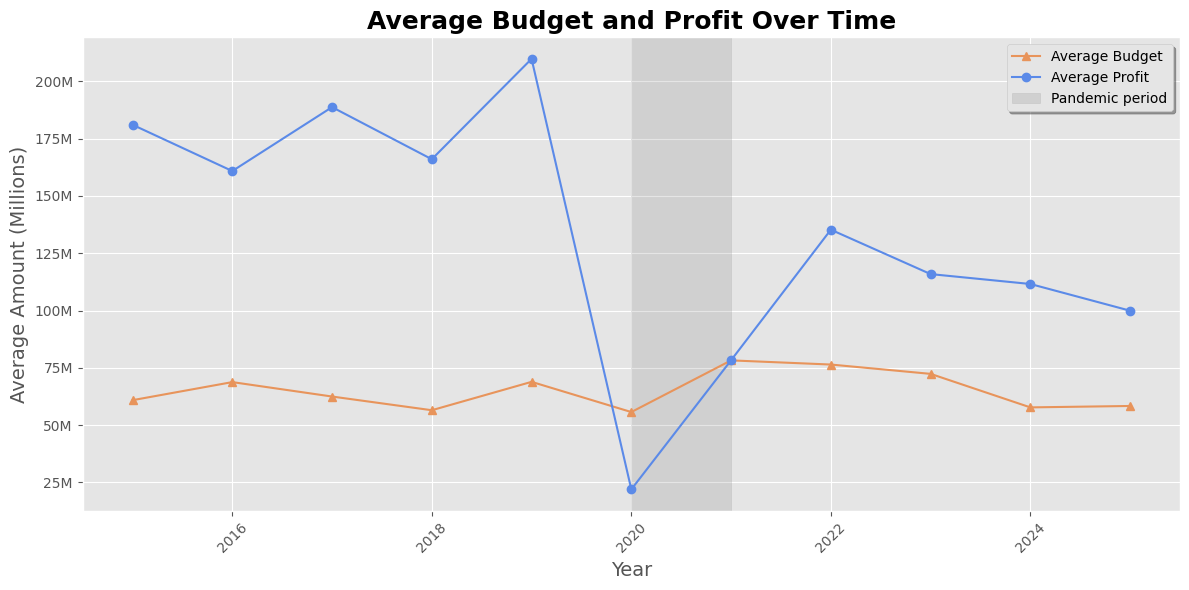

In [136]:

yearly_data = movie_filtered_long.groupby(['release_year'])[['budget', 'profit_long']].mean()

plt.figure(figsize=(12, 6))
ax = yearly_data['budget'].plot(kind='line', marker='^', label='Average Budget', color = '#E8945B')
yearly_data['profit_long'].plot(kind='line', marker='o', ax=ax, label='Average Profit', color = '#5B8AE8')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: str(int(x / 1_000_000)) + 'M'))
plt.style.use('ggplot')
plt.axvspan(2020, 2021, color='gray', alpha=0.2, label='Pandemic period')
plt.title('Average Budget and Profit Over Time', fontsize=18, fontweight='bold')
plt.ylabel('Average Amount (Millions)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.xticks(rotation=45)
plt.legend(shadow=True, loc='upper right', fontsize=10)
plt.tight_layout()


#גרף זה מציג תמונה כללית של הכנסות ותקציבים של סרט בממוצע, על פני תקופת זמן של עשור, כאשר השנים החריגות, שבהן בתי הקולנוע היו סגורים חלקית או באופן מלא. 
ניתן לראות שתקציבי הסרטים לא השתנו באופן משמעותי אחרי המשבר. עם זאת, למרות ההתאוששות שנרשמה ב-2022, בשנים לאחר מכן חלה ירידה, ובשנת 2025 ההכנסות הממוצעות לסרט עומדות על כחצי מהנתון שנרשם בשנת השיא - 2019.

In [16]:
mask1 = (movie['runtime'] >= 90) & (movie['runtime'] <= 200)
mask2 = movie['budget'] > 0
mask3 = (movie['revenue'] > 0) & (~movie['revenue'].isin([5, 7]))
mask4 = movie['original_language'].isin(['en'])
mask5 =(movie['release_year'] >= 2020) & (movie['release_year'] <= 2025)
mask6 = movie['one_genre'].isin(['Action','Adventure','Drama','Horror','Animation','Thriller','Comedy'])

movie_filtered = movie[mask1 & mask2 & mask3 & mask4 & mask5 & mask6]

In [17]:
movie_filtered['profit'] = movie_filtered['revenue'] - movie_filtered['budget']

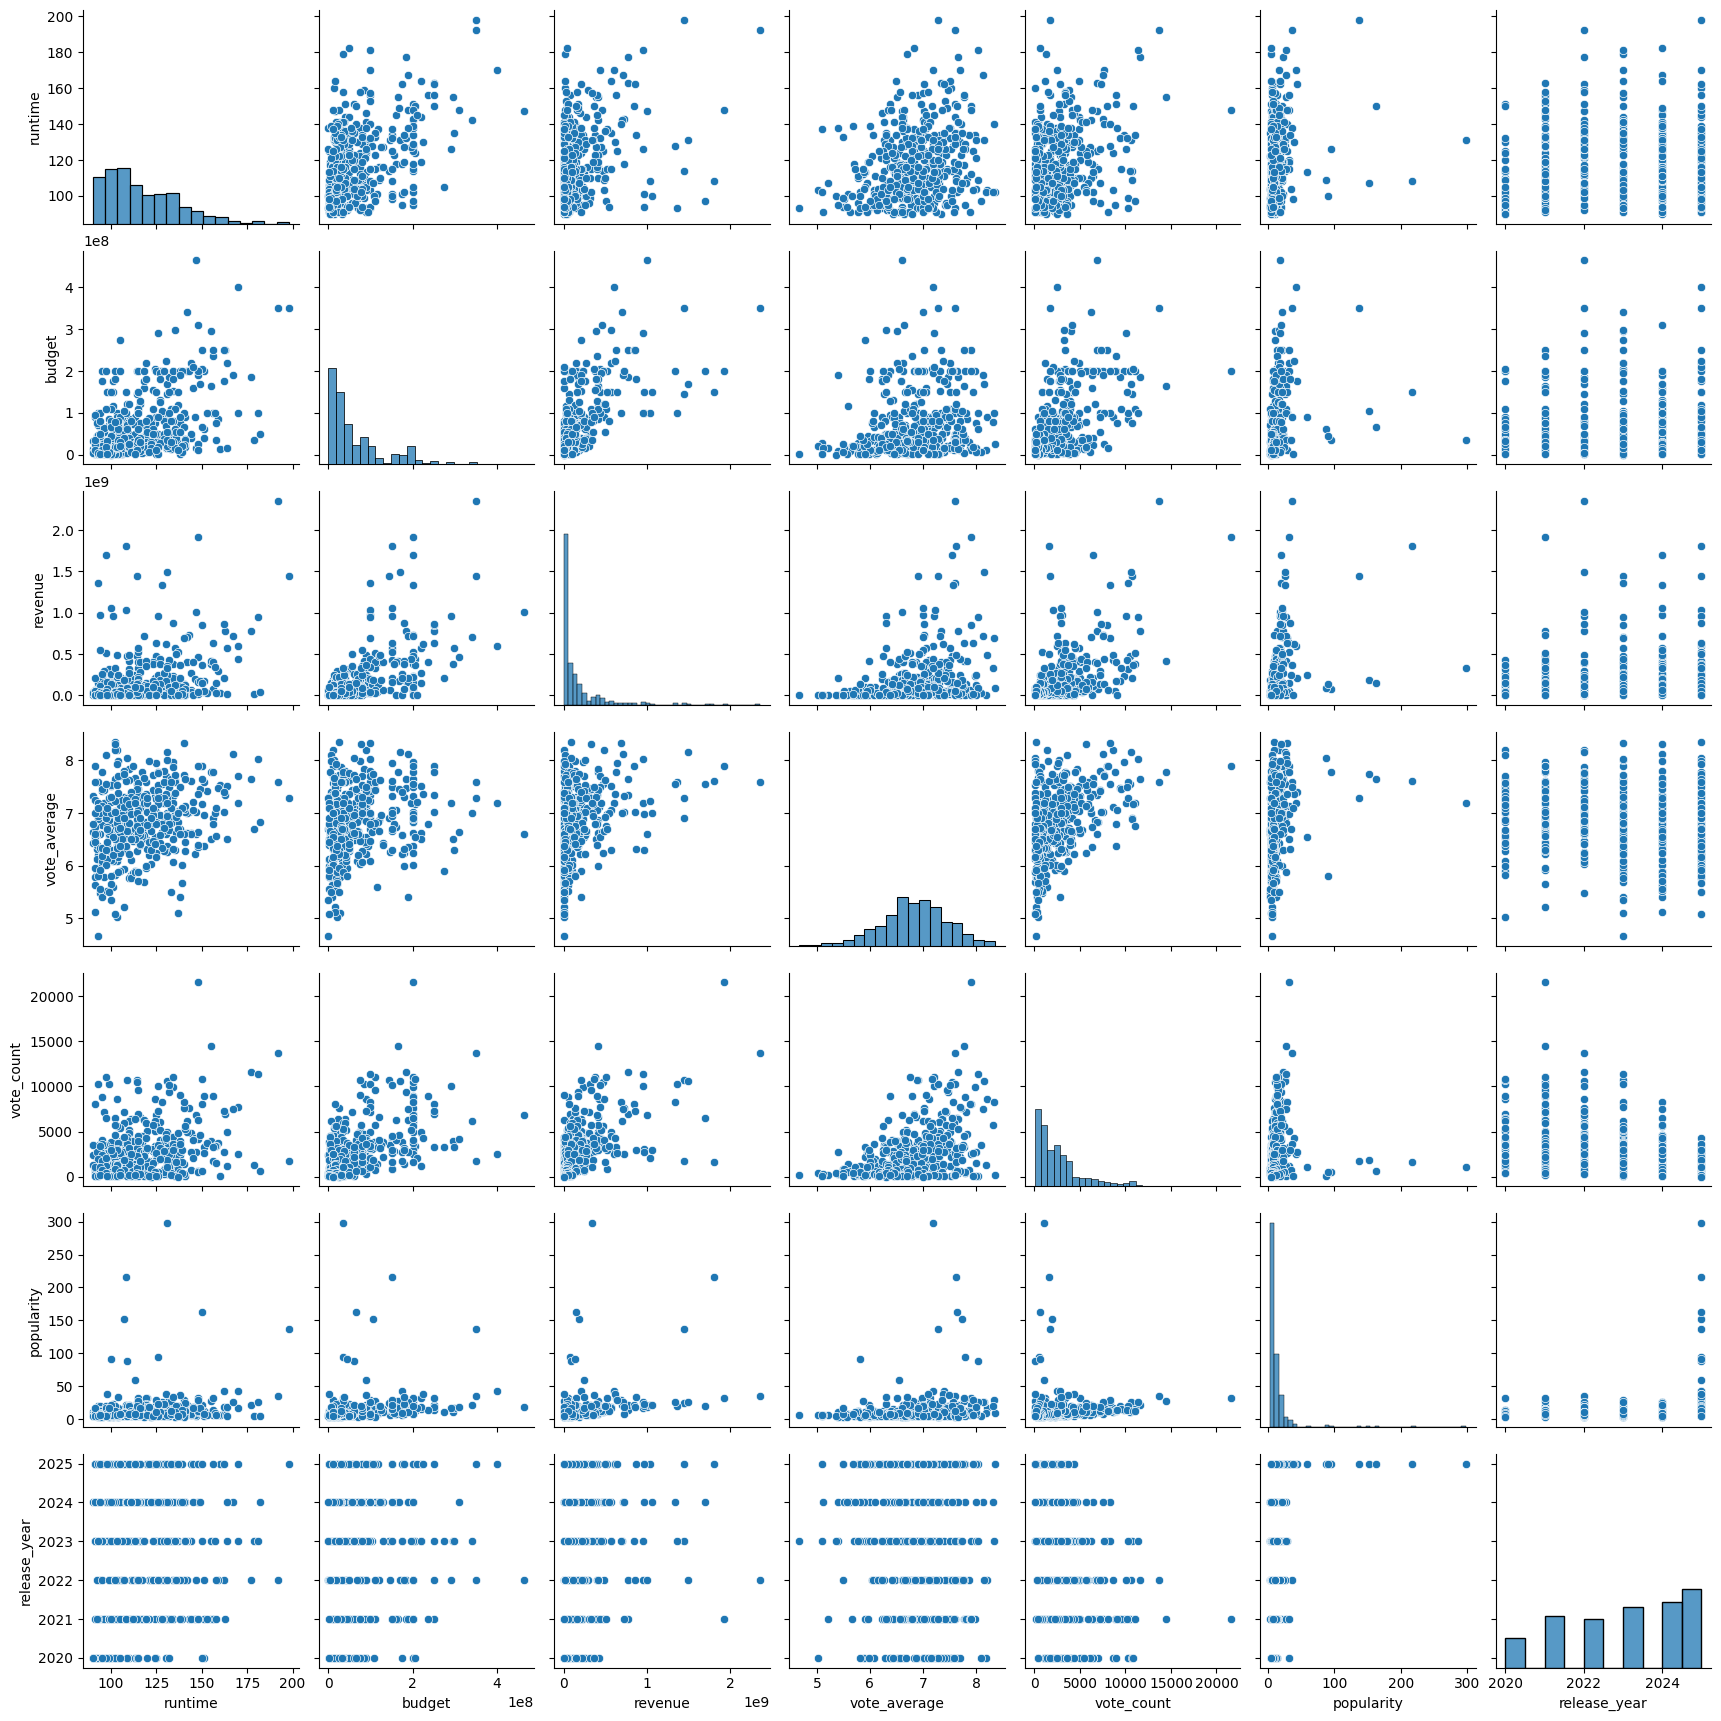

In [119]:
sns.pairplot(movie_filtered)

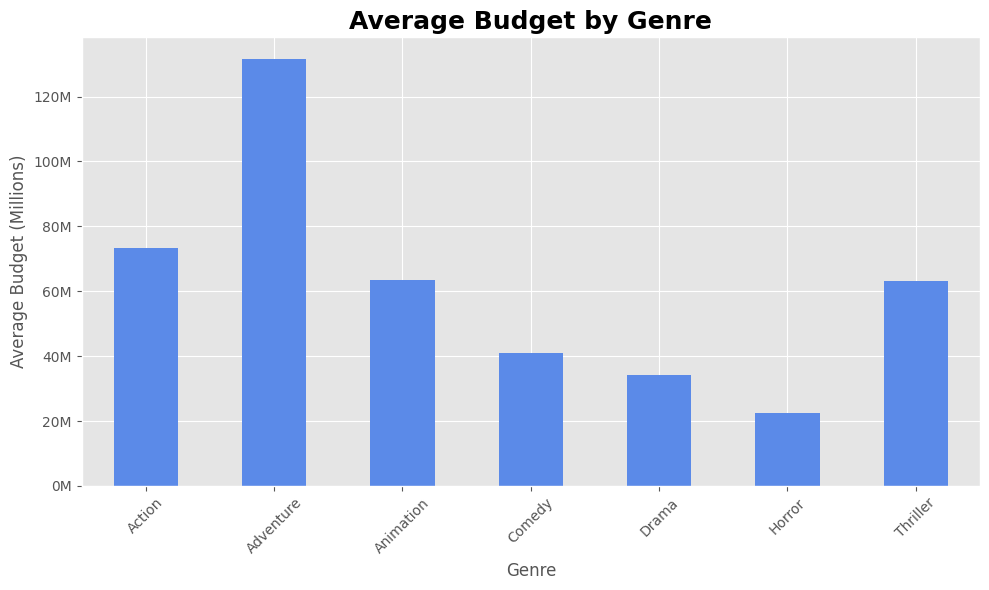

In [88]:
ax = movie_filtered.groupby('one_genre')['budget'].mean().plot(
    kind='bar', color = '#5B8AE8',
    figsize=(10, 6)
)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: str(int(x / 1_000_000)) + 'M'))

plt.ylabel('Average Budget (Millions)')
plt.xlabel('Genre')
plt.title('Average Budget by Genre', fontsize=18, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#גרף זה מציג את התקציב הממוצע לסרט, בפיזור על פני חמש שנים 2020-2025

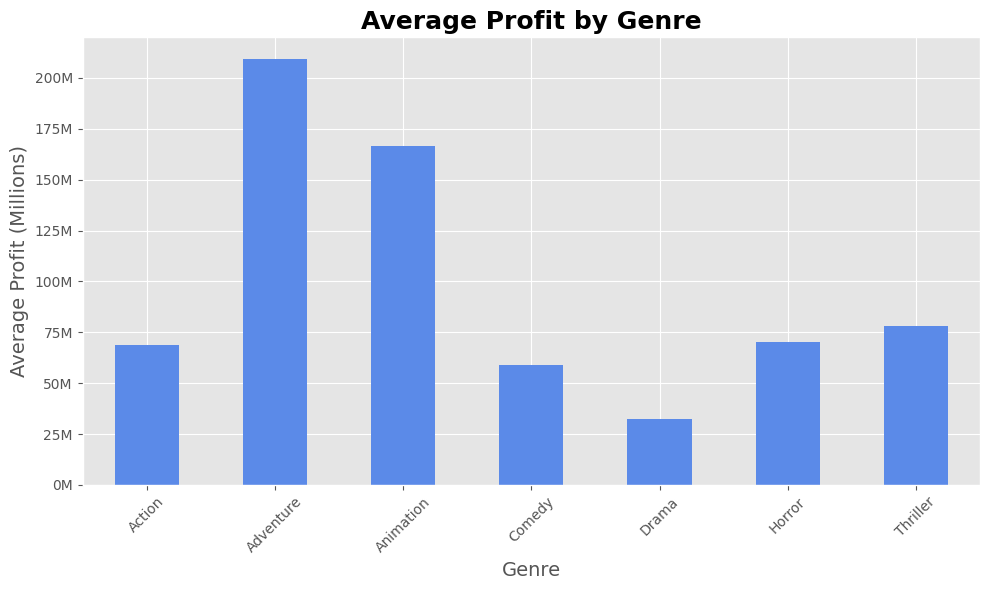

In [92]:
ax = movie_filtered.groupby('one_genre')['profit'].mean().plot(
    kind='bar',
    figsize=(10, 6),
    color = '#5B8AE8'
)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: str(int(x / 1_000_000)) + 'M'))

plt.ylabel('Average Profit (Millions)', fontsize=14)
plt.xlabel('Genre', fontsize=14)
plt.title('Average Profit by Genre', fontsize =18, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#גרף זה מציג את הרווח הממוצע לסרט בטווח השנים שבין 2020 ל-2025. הוא לא נותן הרבה מידע, לכן בגרפים הבאים אפרק את הנתונים כדי להעמיק בניתוח.

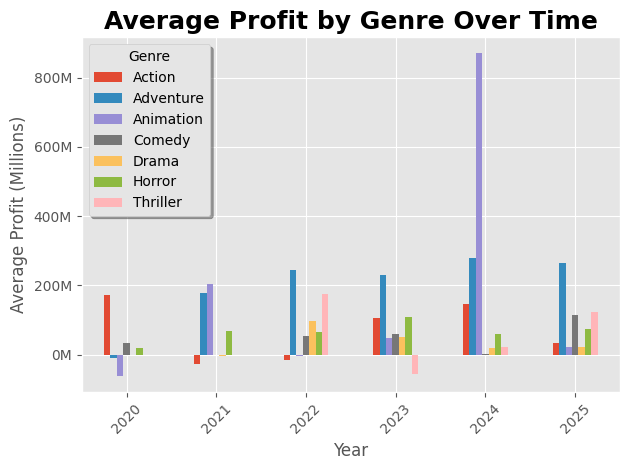

In [93]:
ax= movie_filtered.groupby(['one_genre', 'release_year'])['profit'].mean().unstack(level=0).plot(kind='bar')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: str(int(x / 1_000_000)) + 'M'))
# בשורה מעל: פרמוט המספרים בצורה קריאה
plt.ylabel('Average Profit (Millions)')
plt.xlabel('Year')
plt.legend(title='Genre', shadow=True, loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.title('Average Profit by Genre Over Time', fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#גרף זה מציג את הרווחים הממוצעים של סרט, בהתפלגות הז'אנרים לפי שנה, על מנת לזהות מגמות לאורך שנים. 
#הנתון הבולט ביותר שניתן לגזור מהגרף הוא העקביות שרושם ז'אנר סרטי ההרפתקאות.
#ז'אנר האנימציה, לעומת זאת, שמאופיין במרבית השנים הנתונות כבעל רווח נמוך יחסית, רשם רווח ממוצע גבוה באופן חריג.

In [134]:
pre_covid_movie['pre_profit_margin'] = (pre_covid_movie['revenue'] - pre_covid_movie['budget']) / pre_covid_movie['revenue']
pre_covid_movie.groupby('one_genre')['pre_profit_margin'].mean()

one_genre
Action        0.083376
Adventure    -0.040279
Animation     0.831637
Comedy      -25.188214
Drama       -24.463033
Horror      -10.993399
Thriller    -48.621936
Name: pre_profit_margin, dtype: float64

In [131]:
movie_filtered['profit_margin'] = (movie_filtered['revenue'] - movie_filtered['budget']) / movie_filtered['revenue']

movie_filtered.groupby('one_genre')['profit_margin'].mean()


one_genre
Action      -40.842326
Adventure   -93.455270
Animation    -0.374165
Comedy       -4.592076
Drama       -12.299592
Horror      -15.213512
Thriller    -34.199340
Name: profit_margin, dtype: float64

#על מנת להעמיק את הרזולוציה של רווחיות הסרטים, יצרתי עמודה נוספת המחשבת את שולי הרווח - שיעור הרווח מתוך סך ההכנסות. נתון זה מוסיף הקשר נוסף על נתון הרווח, בכך שהוא מפרט את שיעור ההחזר או ההפסד על כל דולר שהושקע.
#העובדה כי בכל הז'אנרים שולי הרווח הם שליליים, בשילוב הגרפים הקודמים שמראים רווח ממוצע גבוה, מביאים אותי להשערה כי פיזור הרווחים בתוך כל ז'אנר כולל נתוני קיצון שמסיטים את הממוצע כלפי מעלה

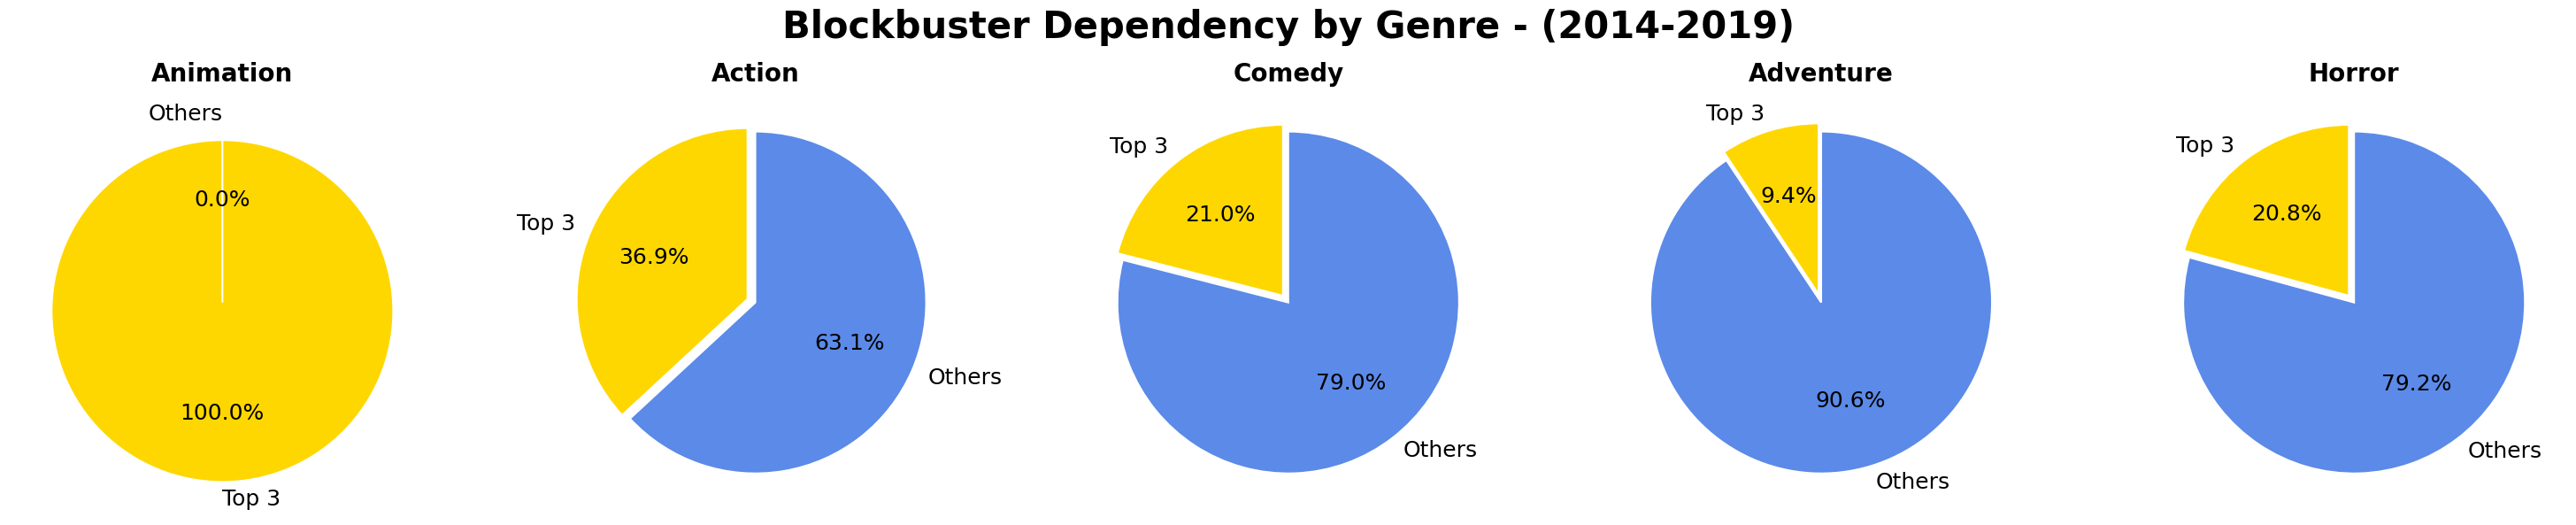

In [94]:
genres_to_plot = ['Animation', 'Action', 'Comedy', 'Adventure', 'Horror']

fig, axes = plt.subplots(1, len(genres_to_plot), figsize=(6 * len(genres_to_plot), 6))

for idx, genre_name in enumerate(genres_to_plot):
    genre_data = pre_covid_movie[pre_covid_movie['one_genre'] == genre_name].copy()
    genre_data['profit'] = genre_data['revenue'] - genre_data['budget']

    top3_profit = genre_data.nlargest(3, 'profit')['profit'].sum()
    other_profit = genre_data['profit'].sum() - top3_profit

    axes[idx].pie(
        [top3_profit, other_profit],
        labels=['Top 3', 'Others'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.05, 0],
        colors=['gold', '#5B8AE8'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 18}
    )
    axes[idx].set_title(genre_name, fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle('Blockbuster Dependency by Genre - (2014-2019)', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()


#לשם ניתוח פיזור הרווחים בתוך ז'אנרים, בחנתי את ההסתמכות על סרטים רווחיים במיוחד.
#ראשית, יצרתי את הגרפים המתבססים על חמש השנים טרום תקופת הקורונה. צומצמה רשימת הז'אנרים שנותחו בשלב הזה על מנת שלא להעמיס בנתונים.
 יצרתי סינון שבוחר את שלושת הסרטים הרווחיים ביותר בכל ז'אנר, וסוכם אותם. לאחר מכן יצגתי את הסכום בגרף עוגה כאחוז מכלל הרווח של אותו הז'אנר. ככל שחלק הפאי המייצג את שלושת הרווחיים ביותר גדול יותר, כך הרווחיות של הז'אנר יציבה פחות, שכן גריעה של סרט אחד מבין שלושת נתוני הקיצון הנ"ל תביא לירידה משמעותית בשורת הרווח.
 #ניתן לראות שז'אנר האנימציה בצורה דרסטית, שכן כלל הרווח הגיע מאותם שלושה סרטים הרווחיים ביותר. 
 #לעומת זאת, בז'אנרי הקומדיה והאימה, כחמישית מהרווחים בלבד הגיעו משלושת הרווחיים ביותר, ובז'אנר ההרפתקאות פחות מעשרה אחוזים.

C:\Users\limor\AppData\Local\Temp\ipykernel_24996\1223205385.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0])


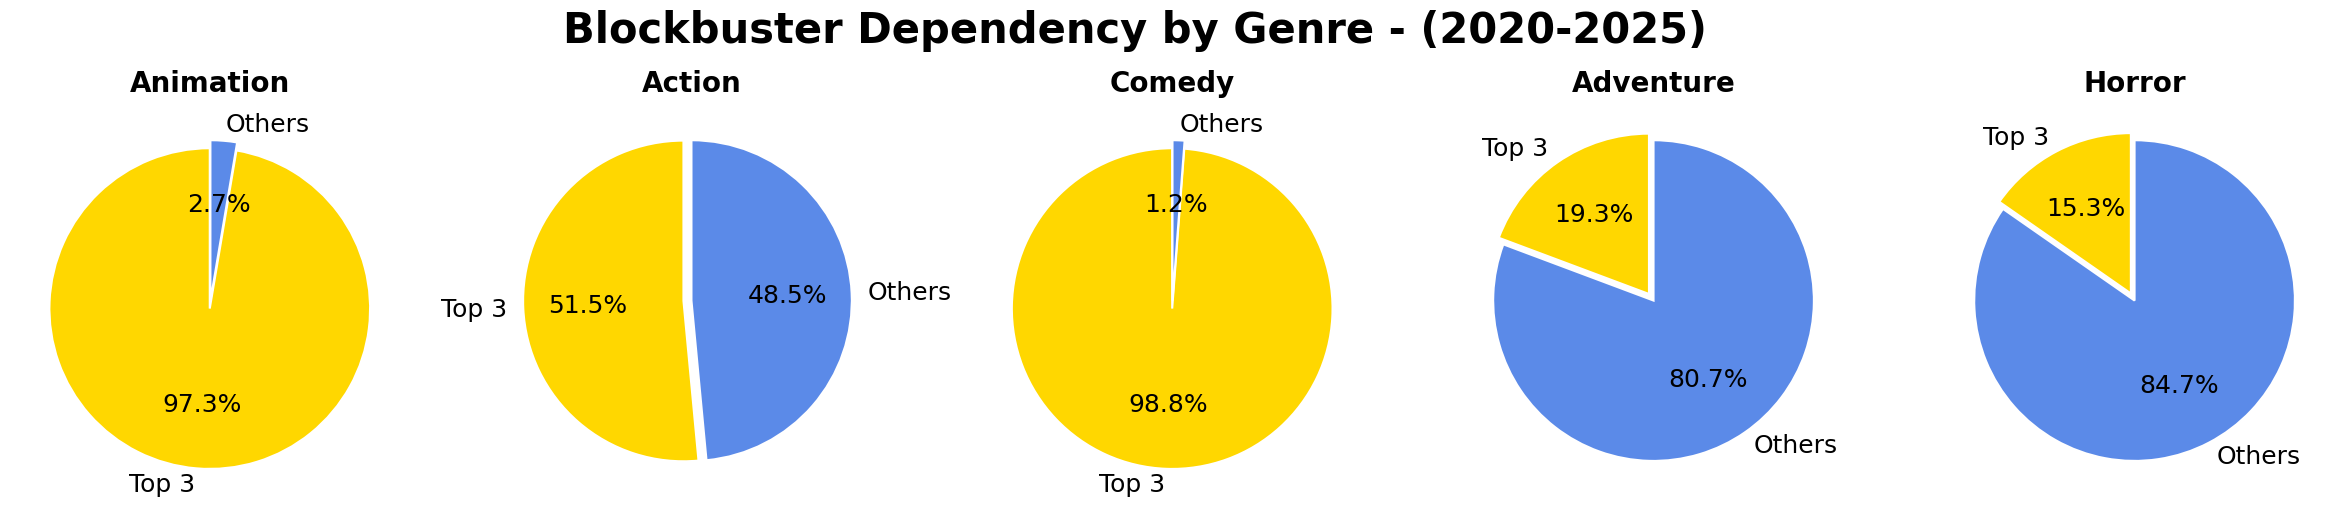

In [101]:
genres_to_plot = ['Animation', 'Action', 'Comedy', 'Adventure', 'Horror']

fig, axes = plt.subplots(1, len(genres_to_plot), figsize=(6 * len(genres_to_plot), 6))

for idx, genre_name in enumerate(genres_to_plot):
    genre_data = movie_filtered[movie_filtered['one_genre'] == genre_name].copy()
    genre_data['profit'] = genre_data['revenue'] - genre_data['budget']

    top3_profit = genre_data.nlargest(3, 'profit')['profit'].sum()
    other_profit = genre_data['profit'].sum() - top3_profit

    axes[idx].pie(
        [top3_profit, other_profit],
        labels=['Top 3', 'Others'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.05, 0],
        colors=['gold', '#5B8AE8'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 18}
    )
    axes[idx].set_title(genre_name, fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0])
fig.suptitle('Blockbuster Dependency by Genre - (2020-2025)', fontsize=30, fontweight='bold')
plt.show()

#כעת אבצע את אותו חישוב על טווח השנים 2020-2025
#בז'אנר האנימציה השינוי זניח ביותר, והוא עדיין מוגדר כלא יציב ברמה גבוהה. ז'אנר הקומדיה, שאופיין בתקופה הקודמת ביציבות בינונית, מצטרף לקטגוריה הלא יציבה.
#ז'אנר הפעולה צמצם בתקופה הנ"ל את התלות שלו בשוברי קופות, וכעת חלקם של הטופ-3 עומד על כמחצית מסך הרווח. 
#ז'אנר האימה שמר על יציבות בינונית ללא שינוי משמעותי. ז'אנר ההרפתקאות עדיין נהנה מיציבות גבוהה יחסית, אך הכפיל את התלות שלו בשוברי קופות.

In [24]:
profitable_movies = movie_filtered[movie_filtered['profit'] > 0]
non_profitable_movies = movie_filtered[movie_filtered['profit'] <= 0]

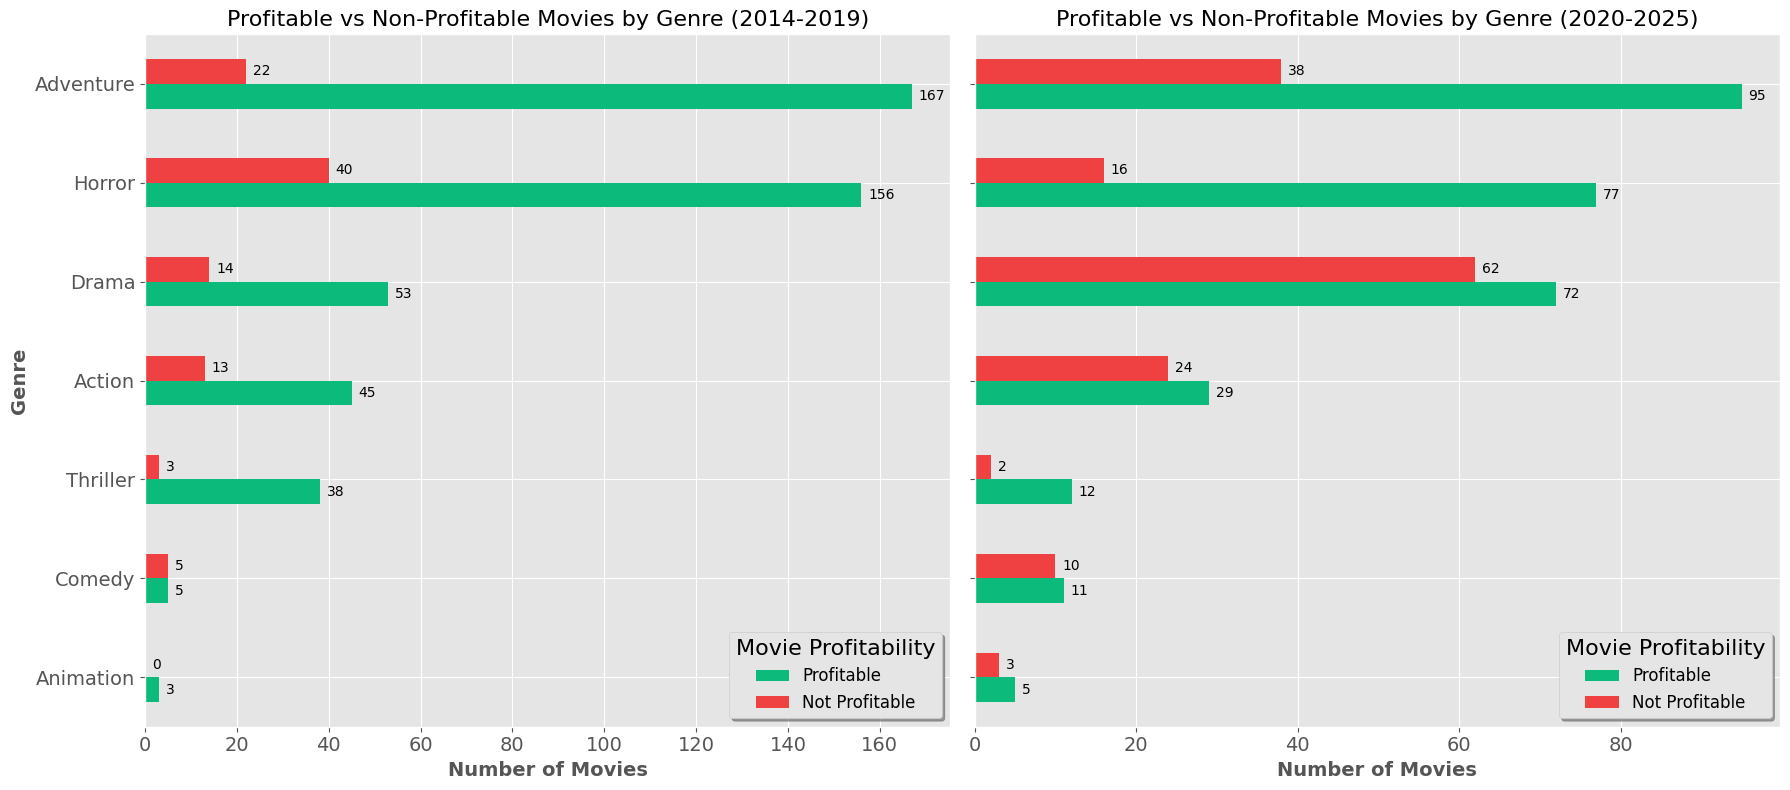

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

pre_profit_counts = pd.concat([
    pre_covid_movie[pre_covid_movie['pre_covid_profit'] > 0]
    .groupby('one_genre')['pre_covid_profit']
    .count()
    .rename('Profitable'),

    pre_covid_movie[pre_covid_movie['pre_covid_profit'] <= 0]
    .groupby('one_genre')['pre_covid_profit']
    .count()
    .rename('Not Profitable')
], axis=1).fillna(0)

pre_profit_counts = pre_profit_counts.sort_values('Profitable')

pre_profit_counts.plot(
    kind='barh',
    ax=axes[0],
    color=['#0CBA7B', '#EF4141']
)

axes[0].set_title('Profitable vs Non-Profitable Movies by Genre (2014-2019)', fontsize=16)
axes[0].set_xlabel('Number of Movies', fontsize=14, weight='bold')
axes[0].legend(title='Movie Profitability', title_fontsize=16, fontsize=12, shadow=True, loc='lower right')
axes[0].tick_params(axis='x', labelsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_ylabel('Genre', fontsize=14, weight='bold')
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=5, fontsize=10)
axes[0].bar_label(axes[0].containers[1], fmt='%d', padding=5, fontsize=10)



post_profit_counts = pd.concat([
    profitable_movies.groupby('one_genre')['profit'].count().rename('Profitable'),
    non_profitable_movies.groupby('one_genre')['profit'].count().rename('Not Profitable')
], axis=1).fillna(0)

post_profit_counts = post_profit_counts.sort_values('Profitable')

post_profit_counts.plot(
    kind='barh',
    ax=axes[1],
    color=['#0CBA7B', '#EF4141']
)

axes[1].set_title('Profitable vs Non-Profitable Movies by Genre (2020-2025)', fontsize=16)
axes[1].set_xlabel('Number of Movies', fontsize=14, weight='bold')
axes[1].set_ylabel('Genre', fontsize=14, weight='bold')
axes[1].legend(title='Movie Profitability', title_fontsize=16, fontsize=12, shadow=True, loc='lower right')
axes[1].tick_params(axis='x', labelsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=5, fontsize=10)
axes[1].bar_label(axes[1].containers[1], fmt='%d', padding=5, fontsize=10)

plt.tight_layout()
plt.show()

#גרף זה מציג את מספר הסרטים הרווחיים בין שתי התקופות.
#ניתן לראות שמרבית הז'אנרים צמצמו את מספר הסרטים שיצאו בתקופה השנייה.
#ז'אנר ההרפתקאות אמנם צמצם את הפער בין מספר הסרטים הרווחיים למספר ההפסדיים, אך הוא עדיין שומר על יחס של 1:2.5 לטובת הרווחיים. 
#ז'אנר האימה צמצם את מספר הסרטים, אך גם שיפר את היחס בין הרווחיים להפסדיים: בתקופה לפני עמד היחס על 1:39, ובתקופה השנייה על 1:4.8.
#ז'אנר הדרמה הוא מהבודדים שרשמו עלייה במספר הסרטים הכולל בתקופת משבר הקורונה ואחריו, עם עלייה של כ-50% במספר הכולל. עם זאת, הפער בין מספר הסרטים הרווחיים להפסדיים הצטמצם משמעותית. לפני המשבר הוא עמד על 1:3.7 לטובת הרווחים, ובתקופה אחרי המשבר על 1:1.1.

##סיכום ומסקנות
משבר הקורונה, בשנים 2020-2021, גרם לפגיעה משמעותית שלא פסחה על אף ז'אנר קולנועי. בשנה שקדמה למשבר היו רווחיו של סרט ממוצע בשיא חיובי, שהראה על התחלה פוטנציאלית של מומנטום צמיחה. בשנת 2022 הפתיחה המחודשת של בתי הקולנוע ברחבי העולם הביאה לעלייה ברווחים, אך בשנים לאחר מכן נרשמת מגמת דעיכה הדרגתית, ובשנה האחרונה שנמדדה במלואה עומד הרווח הממוצע על מעט יותר ממחצית לעומת שנת השיא.
משבר הקורונה שטלטל את השוק מאפשר לבחון את יציבותם של סרטים מז'אנרים שונים.
ז'אנר ההרפתקאות מאופיין בסיכון/רווח הגבוה ביותר, והוא בעל התקציב הממוצע הגבוה ביותר. הן הסרט הרווחי ביותר והן הסרט בעל ההפסד הגבוה ביותר נכנסים תחת הז'אנר הנ"ל. בתקופה לאחר משבר הקורונה, שולי הרווח שלו הם הגבוהים ביותר, וכך גם היחס החיובי בין מספר הסרטים הרווחיים למספר ההפסדיים. ההסתמכות של הז'אנר על שוברי קופות הוכפלה בהשוואה בין התקופות, אך עדיין נותרה ברמה בינונית.
כעת אבחן את ז'אנר האימה, שהוא הז'אנר בעל התקציבים הנמוכים ביותר, ועל כן רמת הסיכון בו היא נמוכה יותר. שולי הרווח של הז'אנר נותרו שליליים, עם שינוי של כ-5% בין התקופות. בנוסף, סרטי הז'אנר צמצמו קלות את התלות בשוברי קופות, והגדילו את היחס בין מספר הסרטים הרווחיים להפסדיים מ1:3.9 לטובת הרווחיים ל-1:4.8.
המלצות לחקר המשך:
יש לעקוב אחר ההסתמכות של ז'אנר ההרפתקאות על שוברי קופות, ולראות האם לאורך השנים הקרובות היחס של הטופ-3 לעומת היתר גדל ומדובר במגמה, או שזהו שינוי נקודתי.


